In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=== 1. CHARGEMENT ET SÉPARATION DES DONNÉES ===")

# 1. Charger les données propres
df = pd.read_csv('../data/processed/retail_customers_clean.csv')

# 2. Séparer les features (X) de la cible (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# CORRECTION ICI : On transforme tout le texte restant en nombres (0 et 1)
print(f"Dimensions de X avant encodage : {X.shape}")
X = pd.get_dummies(X, drop_first=True)
# Si certaines colonnes étaient des booléens (True/False), on force en float
X = X.astype(float) 
print(f"Dimensions de X après encodage : {X.shape}")

# 3. Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nDimensions Train : X={X_train.shape}, y={y_train.shape}")
print(f"Dimensions Test  : X={X_test.shape}, y={y_test.shape}")

# 4. Sauvegarde dans le dossier train_test
os.makedirs('../data/train_test', exist_ok=True)
X_train.to_csv('../data/train_test/X_train.csv', index=False)
X_test.to_csv('../data/train_test/X_test.csv', index=False)
y_train.to_csv('../data/train_test/y_train.csv', index=False)
y_test.to_csv('../data/train_test/y_test.csv', index=False)
print("✅ Données Train/Test sauvegardées et prêtes pour le scaler.")

=== 1. CHARGEMENT ET SÉPARATION DES DONNÉES ===
Dimensions de X avant encodage : (4372, 76)
Dimensions de X après encodage : (4372, 122)

Dimensions Train : X=(3497, 122), y=(3497,)
Dimensions Test  : X=(875, 122), y=(875,)
✅ Données Train/Test sauvegardées et prêtes pour le scaler.


In [5]:
print("\n=== 2. STANDARDISATION ===")

scaler = StandardScaler()

# On apprend (fit) et on transforme le Train
X_train_scaled = scaler.fit_transform(X_train)

# On applique (transform) uniquement sur le Test
X_test_scaled = scaler.transform(X_test)

# On remet sous forme de DataFrame pour garder le nom des colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Standardisation terminée.")


=== 2. STANDARDISATION ===
✅ Standardisation terminée.



=== 3. ENTRAÎNEMENT DU MODÈLE (RANDOM FOREST) ===
✅ Modèle entraîné avec succès.

=== 4. ÉVALUATION DES PERFORMANCES ===

Rapport de Classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875



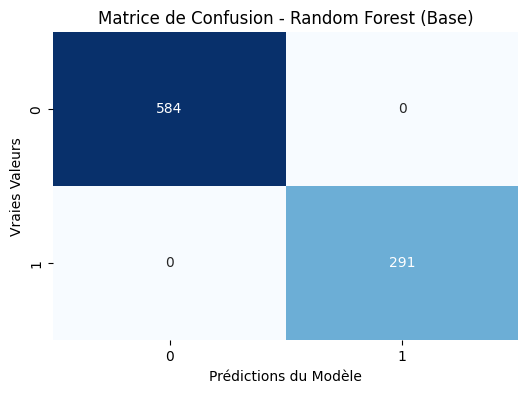

In [6]:
print("\n=== 3. ENTRAÎNEMENT DU MODÈLE (RANDOM FOREST) ===")

# Initialisation du modèle de base
rf_model = RandomForestClassifier(random_state=42)

# Entraînement sur les données d'apprentissage
rf_model.fit(X_train_scaled, y_train)
print("✅ Modèle entraîné avec succès.")

print("\n=== 4. ÉVALUATION DES PERFORMANCES ===")

# Prédictions sur les données de test (que le modèle n'a jamais vues)
y_pred = rf_model.predict(X_test_scaled)

# Affichage du rapport complet
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred))

# Visualisation de la matrice de confusion
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de Confusion - Random Forest (Base)')
plt.ylabel('Vraies Valeurs')
plt.xlabel('Prédictions du Modèle')
plt.show()

In [7]:
import joblib
from sklearn.model_selection import GridSearchCV

print("=== 5. OPTIMISATION DES HYPERPARAMÈTRES (GridSearchCV) ===")

# 1. Définir la grille de paramètres à tester
# (On garde une grille relativement petite pour que ton ordinateur calcule vite)
param_grid = {
    'n_estimators': [50, 100, 200],      # Nombre d'arbres
    'max_depth': [None, 10, 20],         # Profondeur maximale
    'min_samples_split': [2, 5, 10]      # Nombre minimum d'échantillons pour diviser un nœud
}

# 2. Initialiser GridSearchCV
# cv=5 : Validation croisée en 5 parties
# n_jobs=-1 : Utilise toute la puissance de ton processeur
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,          
    n_jobs=-1,     
    verbose=2,     
    scoring='f1'   # On cherche à optimiser le F1-Score car les classes sont déséquilibrées
)

# 3. Lancer la recherche sur le Train
print("Recherche des meilleurs paramètres en cours... (cela peut prendre quelques secondes/minutes)")
grid_search.fit(X_train_scaled, y_train)

# 4. Afficher les résultats
print(f"\n✅ Meilleurs paramètres trouvés : {grid_search.best_params_}")

# On récupère le modèle avec les réglages parfaits
best_rf_model = grid_search.best_estimator_

print("\n=== 6. ÉVALUATION DU MODÈLE OPTIMISÉ ===")
y_pred_best = best_rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best))

print("\n=== 7. SAUVEGARDE DU MODÈLE POUR LA PRODUCTION ===")
# On sauvegarde le modèle pour pouvoir l'utiliser plus tard dans l'API Flask
os.makedirs('../models', exist_ok=True)
model_path = '../models/best_rf_model.joblib'
joblib.dump(best_rf_model, model_path)

# On sauvegarde aussi le scaler (très important pour les futures prédictions)
scaler_path = '../models/scaler.joblib'
joblib.dump(scaler, scaler_path)

print(f"✅ Modèle sauvegardé dans : {model_path}")
print(f"✅ Scaler sauvegardé dans : {scaler_path}")

=== 5. OPTIMISATION DES HYPERPARAMÈTRES (GridSearchCV) ===
Recherche des meilleurs paramètres en cours... (cela peut prendre quelques secondes/minutes)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Meilleurs paramètres trouvés : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

=== 6. ÉVALUATION DU MODÈLE OPTIMISÉ ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875


=== 7. SAUVEGARDE DU MODÈLE POUR LA PRODUCTION ===
✅ Modèle sauvegardé dans : ../models/best_rf_model.joblib
✅ Scaler sauvegardé dans : ../models/scaler.joblib
